In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import h5py as h5

#Quick fudge to make import from ../Scripts work
sys.path.append('../../../common_code/')

#Custom imports
# for color map
import seaborn as sns
# for reading datafiles 
import pandas as pd

# import script that has formation channel classification functions:
from PostProcessingScripts import * 

from formation_channels import * 


from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


# import random # for random no drawing in Formation plot 



In [56]:
def get_primary_secondary(
    m1: Union[float, np.ndarray, u.Quantity] = 0 * u.Msun,
    m2: Union[float, np.ndarray, u.Quantity] = 0 * u.Msun
):
    """
    Return (primary, secondary) where primary >= secondary element-wise.
    
    Parameters
    ----------
    m1, m2 : float, list, np.ndarray, or astropy.units.Quantity
        Component masses. Units are preserved; results always in Msun.
    
    Returns
    -------
    primary, secondary : Quantity
        More massive (primary) and less massive (secondary), in Msun.
    """
    # Convert to Quantity with units
    if not isinstance(m1, u.Quantity):
        m1 = np.asarray(m1) * u.Msun
    if not isinstance(m2, u.Quantity):
        m2 = np.asarray(m2) * u.Msun

    # Convert both to Msun
    m1 = m1.to(u.Msun)
    m2 = m2.to(u.Msun)

    primary = np.maximum(m1, m2)
    secondary = np.minimum(m1, m2)

    return primary, secondary


def chirp_mass(
    m1,
    m2
):
    """
    Compute the chirp mass given component masses m1 and m2.
    
    Parameters
    ----------
    m1, m2 : float, list, np.ndarray, or astropy.units.Quantity
        Component masses. Units are preserved; results always in Msun.
    
    Returns
    -------
    Mc : Quantity
        Chirp mass in Msun.
    """
#     if not isinstance(m1, u.Quantity):
#         m1 = np.asarray(m1, dtype=float) * u.Msun
#     if not isinstance(m2, u.Quantity):
#         m2 = np.asarray(m2, dtype=float) * u.Msun

#     # Convert both to Msun
#     m1 = m1 #.to(u.Msun)
#     m2 = m2#.to(u.Msun)

    mc = (m1 * m2) ** (3/5) / ((m1 + m2) ** (1/5))
    return mc #.to(u.Msun).value


In [14]:
! ls /Volumes/SimonsFoundation/DataDCO

alpha0_1                         massTransferEfficiencyFixed_0_75
alpha0_5                         maxNSmass2_0
alpha10                          maxNSmass3_0
alpha2_0                         noBHkick
ccSNkick_100km_s                 noPISN
ccSNkick_30km_s                  rapid
fiducial                         unstableCaseBB
massTransferEfficiencyFixed_0_25 wolf_rayet_multiplier_0_1
massTransferEfficiencyFixed_0_5  wolf_rayet_multiplier_5


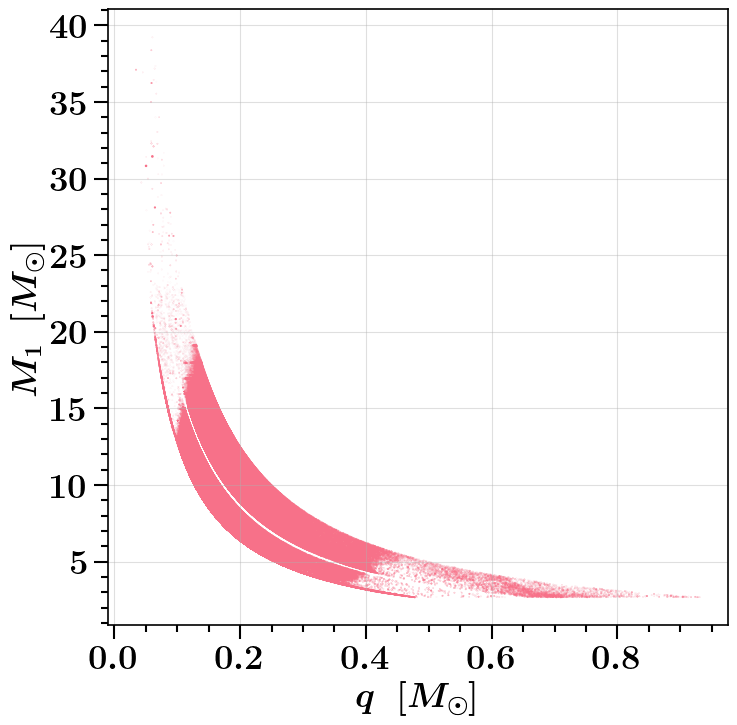

In [45]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
BPSmodelName = 'A'
xparam = 'DCO_q'
yparam = 'DCO_M1'
DCOtype = 'BHNS'
# for ind_bps, BPSmodelName in enumerate(['A', 'B', 'C', 'D', 'G', 'H', 'I', 'J' ]):
# for ind_bps, BPSmodelName in enumerate(['A']):


#####
DCOname = DCOname_dict[DCOtype]

# path for files 
path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

fdata = h5.File(path)
fDCO = fdata['doubleCompactObjects']     

DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()]
M1 = fdata['doubleCompactObjects']['M1'][()]
M2 = fdata['doubleCompactObjects']['M2'][()]

DCO_Mc = chirp_mass(DCO_M1, DCO_M2)
DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
DCO_q  =  DCO_M2/DCO_M1

w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 

dict_xparam = {
    'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
    'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
    'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
    'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
    'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
    'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'}
}

x_vals = dict_xparam[xparam]['param']
y_vals = dict_xparam[yparam]['param']


layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)
ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

fdata.close()


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T


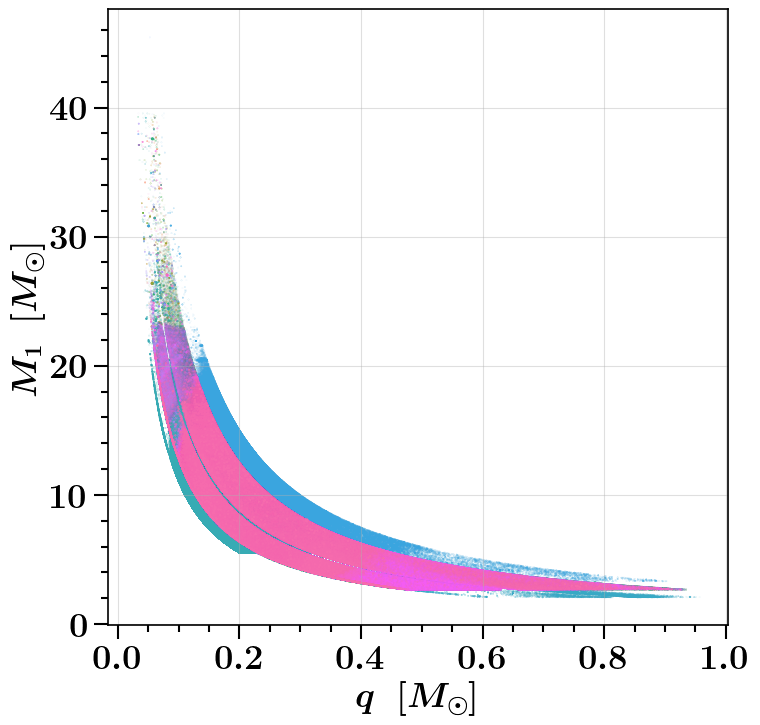

In [51]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
# BPSmodelName = 'A'
xparam = 'DCO_q'
yparam = 'DCO_M1'
DCOtype = 'BHNS'

# for ind_bps, BPSmodelName in enumerate(['A']):


#####



for ind_bps, BPSmodelName in enumerate(BPSnameslist):
#     print(BPSmodelName)
    DCOname = DCOname_dict[DCOtype]

    # path for files 
    path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
    path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

    fdata = h5.File(path)
    fDCO = fdata['doubleCompactObjects']     

    DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()]
    M1 = fdata['doubleCompactObjects']['M1'][()]
    M2 = fdata['doubleCompactObjects']['M2'][()]

    DCO_Mc =  (M1 * M2) ** (3/5) / ((M1 + M2) ** (1/5))
    DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
    DCO_q  =  DCO_M2/DCO_M1

    w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 
    
    dict_xparam = {
        'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
        'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
        'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
        'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
        'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
        'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'}
    }
    
    
    x_vals = dict_xparam[xparam]['param']
    y_vals = dict_xparam[yparam]['param']
    ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

    fdata.close()

# beautify axes
layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

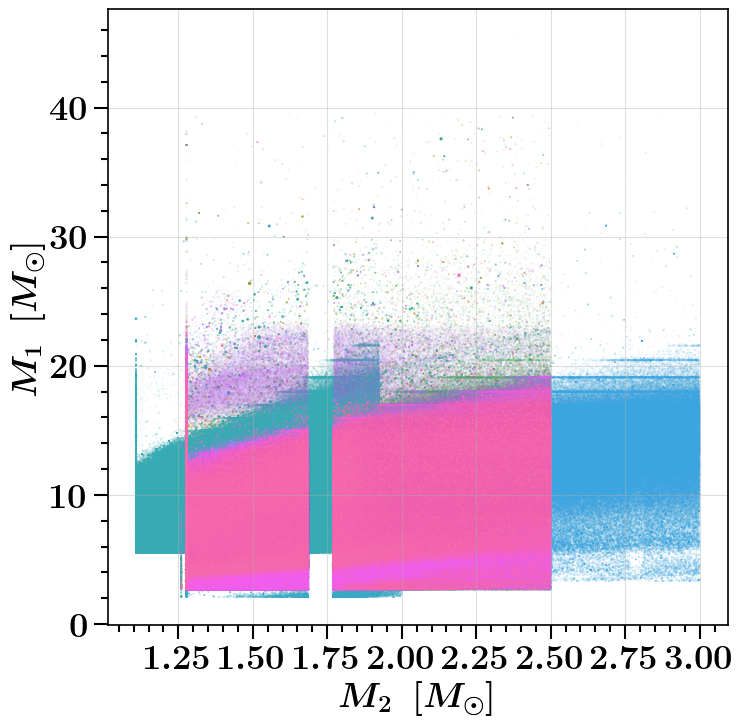

In [52]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
# BPSmodelName = 'A'
xparam = 'DCO_M2'
yparam = 'DCO_M1'
DCOtype = 'BHNS'

# for ind_bps, BPSmodelName in enumerate(['A']):


#####



for ind_bps, BPSmodelName in enumerate(BPSnameslist):
#     print(BPSmodelName)
    DCOname = DCOname_dict[DCOtype]

    # path for files 
    path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
    path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

    fdata = h5.File(path)
    fDCO = fdata['doubleCompactObjects']     

    DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()]
    M1 = fdata['doubleCompactObjects']['M1'][()]
    M2 = fdata['doubleCompactObjects']['M2'][()]

    DCO_Mc = chirp_mass(DCO_M1, DCO_M2)
    DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
    DCO_q  =  DCO_M2/DCO_M1

    w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 
    
    dict_xparam = {
        'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
        'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
        'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
        'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
        'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
        'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'}
    }
    
    
    x_vals = dict_xparam[xparam]['param']
    y_vals = dict_xparam[yparam]['param']
    ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

    fdata.close()

# beautify axes
layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

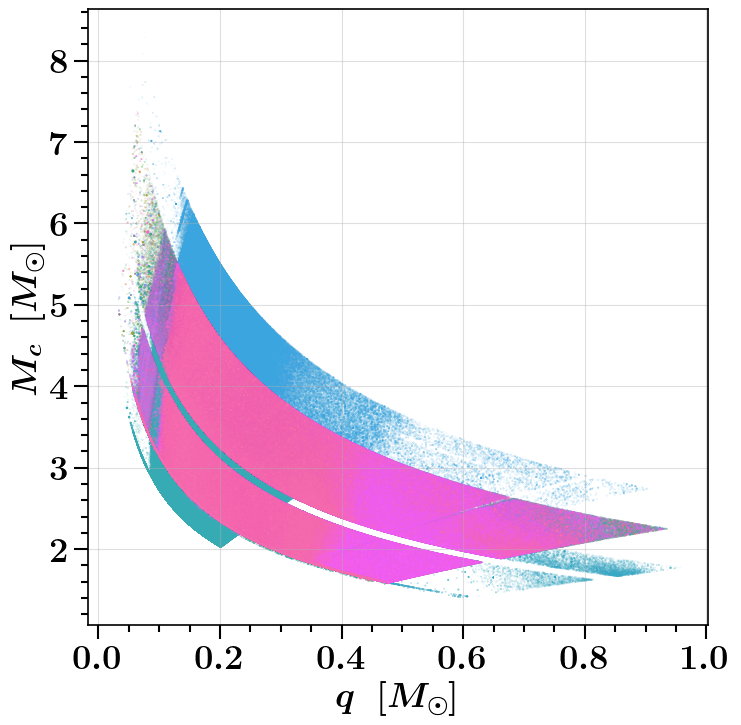

In [58]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
# BPSmodelName = 'A'
xparam = 'DCO_q'
yparam = 'DCO_Mc'
DCOtype = 'BHNS'

# for ind_bps, BPSmodelName in enumerate(['A']):


#####



for ind_bps, BPSmodelName in enumerate(BPSnameslist):
#     print(BPSmodelName)
    DCOname = DCOname_dict[DCOtype]

    # path for files 
    path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
    path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

    fdata = h5.File(path)
    fDCO = fdata['doubleCompactObjects']     

    DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()]
    M1 = fdata['doubleCompactObjects']['M1'][()]
    M2 = fdata['doubleCompactObjects']['M2'][()]

    DCO_Mc =  (M1 * M2) ** (3/5) / ((M1 + M2) ** (1/5))
    DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
    DCO_q  =  DCO_M2/DCO_M1

    w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 
    
    dict_xparam = {
        'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
        'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
        'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
        'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
        'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
        'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'}
    }
    
    
    x_vals = dict_xparam[xparam]['param']
    y_vals = dict_xparam[yparam]['param']
    ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

    fdata.close()

# beautify axes
layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

In [ ]:
### Add spins 

0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
2  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set th

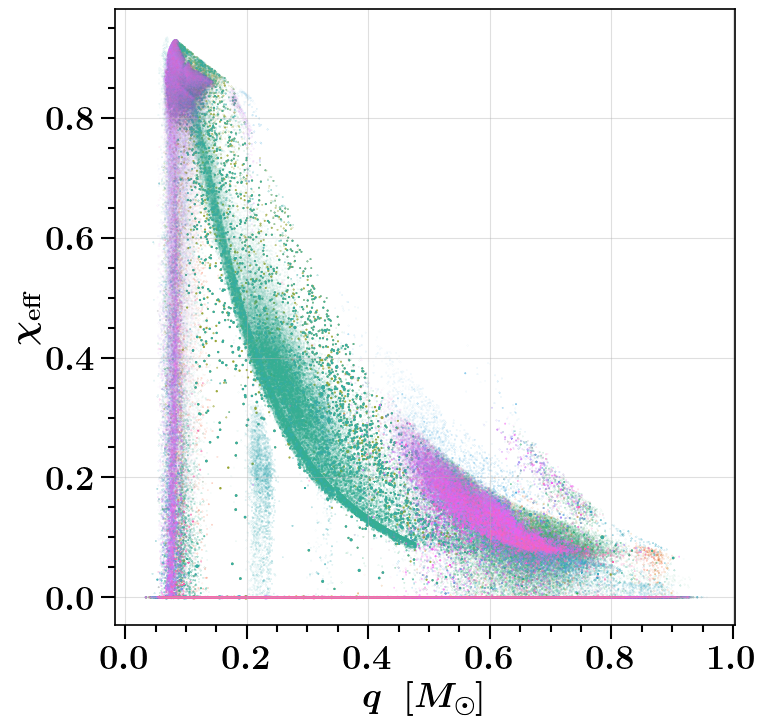

In [64]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
# BPSmodelName = 'A'
xparam = 'DCO_q'
yparam = 'chi_effective'
DCOtype = 'BHNS'

# for ind_bps, BPSmodelName in enumerate(['A']):


#####



for ind_bps, BPSmodelName in enumerate(BPSnameslist):
#     print(BPSmodelName)
    DCOname = DCOname_dict[DCOtype]

    # path for files 
    path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
    path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

    fdata = h5.File(path)
    fDCO = fdata['doubleCompactObjects']     

    DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()].squeeze()
    M1 = fdata['doubleCompactObjects']['M1'][()].squeeze()
    M2 = fdata['doubleCompactObjects']['M2'][()].squeeze()

    DCO_Mc =  (M1 * M2) ** (3/5) / ((M1 + M2) ** (1/5))
    DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
    DCO_q  =  DCO_M2/DCO_M1
    
    
    spin = COspin(data_path=path, state='he_depletion')  # set class 
    spin.setCOMPASData() # reads in the COMPAS DCO parameters 
    spinZAMSM1, spinZAMSM2  = spin.BaveraSpin() #ZAMS M1 SPIN 
    
    mask_MRR = (M2>M1) 

    spinLVKM1, spinLVKM2 = np.zeros_like(spinZAMSM1), np.zeros_like(spinZAMSM1)
    spinLVKM1[mask_MRR] = spinZAMSM2[mask_MRR]  # MRR so M1 comes from M2ZAMS, we assign it spin from M2ZAMS
    spinLVKM1[~mask_MRR] = spinZAMSM1[~mask_MRR]  # no MRR so M1 comes from M1ZAMS, we assign it spin from M1ZAMS
    spinLVKM2[mask_MRR] = spinZAMSM1[mask_MRR]   # MRR so M2 comes from M1ZAMS, we assign it spin from M1ZAMS
    spinLVKM2[~mask_MRR] = spinZAMSM2[~mask_MRR]   # no MRR so M2 comes from M2ZAMS, we assign it spin from M2ZAMS     

    chi_effective = ((spinLVKM1*DCO_M1) + (spinLVKM2*DCO_M2)) / (DCO_M1+DCO_M2)



    w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 
    
    dict_xparam = {
        'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
        'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
        'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
        'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
        'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
        'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'},
        'chi_effective': {'param':chi_effective,  'ax_label':r'$\chi_{\rm{eff}}$ '}
    }
    
    
    x_vals = dict_xparam[xparam]['param']
    y_vals = dict_xparam[yparam]['param']
    ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

    fdata.close()

# beautify axes
layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
2  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set th

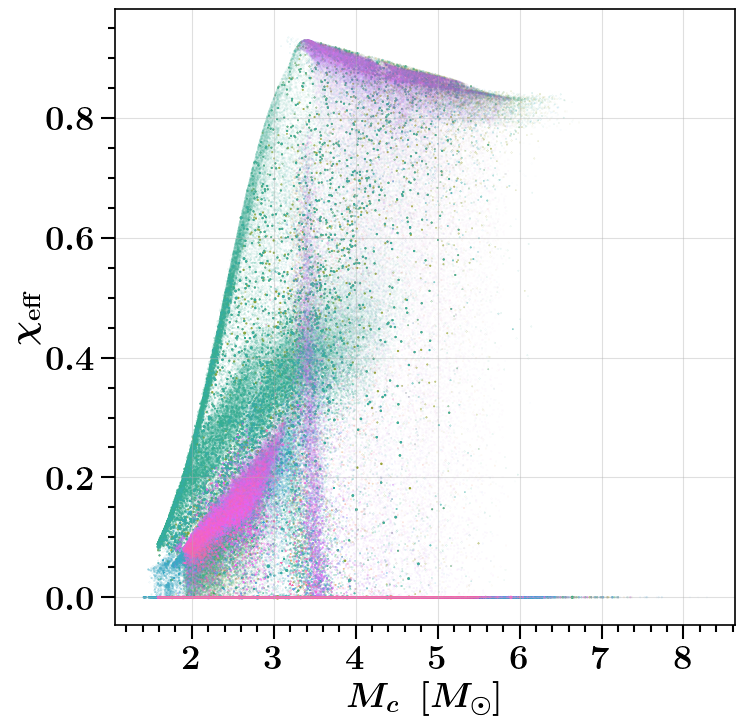

In [65]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
# BPSmodelName = 'A'
xparam = 'DCO_Mc'
yparam = 'chi_effective'
DCOtype = 'BHNS'

# for ind_bps, BPSmodelName in enumerate(['A']):


#####



for ind_bps, BPSmodelName in enumerate(BPSnameslist):
#     print(BPSmodelName)
    DCOname = DCOname_dict[DCOtype]

    # path for files 
    path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
    path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

    fdata = h5.File(path)
    fDCO = fdata['doubleCompactObjects']     

    DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()].squeeze()
    M1 = fdata['doubleCompactObjects']['M1'][()].squeeze()
    M2 = fdata['doubleCompactObjects']['M2'][()].squeeze()

    DCO_Mc =  (M1 * M2) ** (3/5) / ((M1 + M2) ** (1/5))
    DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
    DCO_q  =  DCO_M2/DCO_M1
    
    
    spin = COspin(data_path=path, state='he_depletion')  # set class 
    spin.setCOMPASData() # reads in the COMPAS DCO parameters 
    spinZAMSM1, spinZAMSM2  = spin.BaveraSpin() #ZAMS M1 SPIN 
    
    mask_MRR = (M2>M1) 

    spinLVKM1, spinLVKM2 = np.zeros_like(spinZAMSM1), np.zeros_like(spinZAMSM1)
    spinLVKM1[mask_MRR] = spinZAMSM2[mask_MRR]  # MRR so M1 comes from M2ZAMS, we assign it spin from M2ZAMS
    spinLVKM1[~mask_MRR] = spinZAMSM1[~mask_MRR]  # no MRR so M1 comes from M1ZAMS, we assign it spin from M1ZAMS
    spinLVKM2[mask_MRR] = spinZAMSM1[mask_MRR]   # MRR so M2 comes from M1ZAMS, we assign it spin from M1ZAMS
    spinLVKM2[~mask_MRR] = spinZAMSM2[~mask_MRR]   # no MRR so M2 comes from M2ZAMS, we assign it spin from M2ZAMS     

    chi_effective = ((spinLVKM1*DCO_M1) + (spinLVKM2*DCO_M2)) / (DCO_M1+DCO_M2)



    w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 
    
    dict_xparam = {
        'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
        'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
        'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
        'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
        'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
        'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'},
        'chi_effective': {'param':chi_effective,  'ax_label':r'$\chi_{\rm{eff}}$ '}
    }
    
    
    x_vals = dict_xparam[xparam]['param']
    y_vals = dict_xparam[yparam]['param']
    ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

    fdata.close()

# beautify axes
layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

In [ ]:
ncols=1
nrows=1
f, ax= plt.subplots(ncols=ncols,nrows=nrows,figsize=(8,8), 
              gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})
# BPSmodelName = 'A'
xparam = 'DCO_M1'
yparam = 'chi_effective'
DCOtype = 'BHNS'

# for ind_bps, BPSmodelName in enumerate(['A']):


#####



for ind_bps, BPSmodelName in enumerate(BPSnameslist):
#     print(BPSmodelName)
    DCOname = DCOname_dict[DCOtype]

    # path for files 
    path_ = '/Volumes/SimonsFoundation/DataDCO/' + alphabetDirDict[BPSmodelName] +'/'
    path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

    fdata = h5.File(path)
    fDCO = fdata['doubleCompactObjects']     

    DCO_fc = fdata['doubleCompactObjects']['formaton channel'][()].squeeze()
    M1 = fdata['doubleCompactObjects']['M1'][()].squeeze()
    M2 = fdata['doubleCompactObjects']['M2'][()].squeeze()

    DCO_Mc =  (M1 * M2) ** (3/5) / ((M1 + M2) ** (1/5))
    DCO_M1, DCO_M2 = obtainM1BHandM2BHassymetric(m1=M1, m2=M2) 
    DCO_q  =  DCO_M2/DCO_M1
    
    
    spin = COspin(data_path=path, state='he_depletion')  # set class 
    spin.setCOMPASData() # reads in the COMPAS DCO parameters 
    spinZAMSM1, spinZAMSM2  = spin.BaveraSpin() #ZAMS M1 SPIN 
    
    mask_MRR = (M2>M1) 

    spinLVKM1, spinLVKM2 = np.zeros_like(spinZAMSM1), np.zeros_like(spinZAMSM1)
    spinLVKM1[mask_MRR] = spinZAMSM2[mask_MRR]  # MRR so M1 comes from M2ZAMS, we assign it spin from M2ZAMS
    spinLVKM1[~mask_MRR] = spinZAMSM1[~mask_MRR]  # no MRR so M1 comes from M1ZAMS, we assign it spin from M1ZAMS
    spinLVKM2[mask_MRR] = spinZAMSM1[mask_MRR]   # MRR so M2 comes from M1ZAMS, we assign it spin from M1ZAMS
    spinLVKM2[~mask_MRR] = spinZAMSM2[~mask_MRR]   # no MRR so M2 comes from M2ZAMS, we assign it spin from M2ZAMS     

    chi_effective = ((spinLVKM1*DCO_M1) + (np.zeros_like(spinLVKM2)*DCO_M2)) / (DCO_M1+DCO_M2)



    w_312 = fdata['weights_intrinsicPerRedshift']['w_321_z_0.1923'][()] # intrinsic weights 
    
    dict_xparam = {
        'DCO_M1':{'param':DCO_M1, r'ax_label':r'$M_1$ $\ [M_{\odot}]$'},
        'DCO_M2':{'param':DCO_M2, r'ax_label':r'$M_2$ $\ [M_{\odot}]$'}, 
        'M1':{'param':M1, 'ax_label':r'$M_{1,ZAMS}$ $\[M_{\odot}]$'},
        'M2':{'param':M2, 'ax_label':r'$M_{2,ZAMS}$ $\ [M_{\odot}]$'}, 
        'DCO_Mc':{'param':DCO_Mc, 'ax_label':r'$M_c$ $ \ [M_{\odot}]$'},
        'DCO_q': {'param':DCO_q,  'ax_label':r'$q$ $ \ [M_{\odot}]$'},
        'chi_effective': {'param':chi_effective,  'ax_label':r'$\chi_{\rm{eff}}$ '}
    }
    
    
    x_vals = dict_xparam[xparam]['param']
    y_vals = dict_xparam[yparam]['param']
    ax.scatter(x_vals, y_vals, s=(20*w_312), c=[colorDirDict[BPSmodelName]])

    fdata.close()

# beautify axes
layoutAxes(ax=ax, nameX=dict_xparam[xparam]['ax_label'], nameY=dict_xparam[yparam]['ax_label'])

ax.grid(True, alpha=0.4)


save_str = DCOtype + '_' + xparam + '_'+ yparam + '.png'
# plt.savefig(save_str, transparent=False, dpi=400)
plt.show()

0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
2  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set these to 0 
0  systems had negative spin because they are outside of the boundary conditions; we set th

In [ ]:
# # BPSmodelName ='A' # fiducial 
# # mssfr = '000' # fiducial 
# ############
# ######
# # for ind_bps, BPSmodelName in enumerate(BPSnameslist):
# for ind_bps, BPSmodelName in enumerate(['A', 'B', 'C', 'D', 'G', 'H', 'I', 'J' ]):
#     ncols=1
#     nrows=1
#     f, axes= plt.subplots(ncols=ncols,nrows=nrows,figsize=(24,12), 
#                   gridspec_kw={"width_ratios":1.5*np.ones(ncols), "height_ratios":1*np.ones(nrows)})


#     channelColorDict = {1:'#118AB2', 2:'#EF476F', 3:'#FFD166', 4:'#073B4C', 0:'gray'}  

#     s_text = r'model %s: '%BPSmodelName + alphabetPhysicalNameDictWithEnter[BPSmodelName]
#     axes.text(0.98, 0.97, s=s_text , rotation = 0, fontsize = fs, color = 'k', va='top', ha = 'right',transform=axes.transAxes)#, weight = 'bold')
# #     axes.set_ylim(-3, 1.2)
# #     plot_3Msun_lines(axes=axes, xlim=[2,400])
#     make_up_axes(axes=axes, ylim=[0, 50],  xlim=[-3, 1.2], ylabel=r'M1BH $[M_{\odot}]$', xlabel=r'$\log_{10}(t_{\rm{delay}}) \ [\rm{Gyr}]$', logX=False) 
# #     plot_x_ticks(axe=axes) # has to go after make_up_axes 
#     w_size=100
# #     add_GW_credible_intervals(axes=axes)
# #     for ind_dco, DCOtype in enumerate(['BNS']):
#     for ind_dco, DCOtype in enumerate(['BBH']):#, 'BNS', 'BHNS']):

#         print('now at DCOtype %s'%DCOtype)

#         #####
#         DCOname = DCOname_dict[DCOtype]

#         # path for files 
#         path_ = '/Volumes/Andromeda/DATA/AllDCO_bugfix/' + alphabetDirDict[BPSmodelName] +'/'
#         path  = path_ + 'COMPASCompactOutput_'+ DCOtype +'_' + BPSmodelName + '.h5'

#         # read in data 
#         fdata = h5.File(path)

#         seeds = fdata['doubleCompactObjects']['seed'][...].squeeze()
#         channels = identify_formation_channels(seeds=seeds, file=fdata)
        

#         tc = fdata['doubleCompactObjects']['tc'][...].squeeze()
#         tform = fdata['doubleCompactObjects']['tform'][...].squeeze()
#         log10tdelay= np.log10((tc/1000) + (tform / 1000)) # in log10 and Gyr 
#         del tc 
#         del tform
        
        
        

#         # M1 will be the most massive, M2 the least massive compact object. 
#         M1, M2 = obtainM1BHandM2BHassymetric(m1=fdata['doubleCompactObjects']['M1'][...].squeeze(), m2=fdata['doubleCompactObjects']['M2'][...].squeeze()) 
#         #     Chirpmass = chirpmass(M1[mask_c],M2[mask_c])

        
        
#         ### read in MSSFR weights: ###
#         mssfr = '312' # mssfr that matches LIGO observed rates.
#         # get detected weights
# #         fparam_key = 'weights_detected'
# #         weightheader = 'w_' + mssfr
#         w = fdata['doubleCompactObjects']['weight'][...].squeeze()
        
#         # pick per DCO N (size_boot) representative samples, based on Detectable weights 
#         size_boot = 5000
#         boot_index = np.arange(len(seeds))
#         boot_randindex = np.random.choice(boot_index, size=size_boot, replace=True, p=w/np.sum(w))  # prob needs to be normalized  
        

#         for ind_c, Channel in enumerate([0,1,2,3,4]):

#             mask_c  = (channels[boot_randindex]==Channel) 
#             if np.sum(mask_c)>0:

#                 M1BH_ = M1[boot_randindex][mask_c] #+ M2[boot_randindex][mask_c] 
#                 log10tdelay_ = log10tdelay[boot_randindex][mask_c] 
# #                 massRatio = M2[boot_randindex][mask_c]/M1[boot_randindex][mask_c]
# #                 print()
# #                 print(len(np.random.choice([1,2,3,4,5], size=len(Mtot))))
# #                 print(((np.random.choice([1,2,3,4,5], size=len(Mtot)))))
# #                 zorder = (np.random.choice([1,2,3,4,5], size=len(Mtot)))
#                 plt.scatter(log10tdelay_, M1BH_,   c=channelColorDict[Channel], s=7, alpha=1, zorder=1)
# #                 print('done')

#             else:
#                 print('skip channel %s'%Channel)

#         plt.tight_layout()
#         plt.savefig('/Users/floorbroekgaarden/Projects/GitHub/DCO_FormationChannels/plottingCode/Fig_2/vs_PsimulationWeighted_M1BH_logtdelay/Formation_channel_' + BPSmodelName  + '_'+ str(ind_dco) + '.png', dpi=300, transparent=False)
    
    
#     plt.show()
#     plt.close()